In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import root_mean_squared_error

In [40]:
df = pd.read_csv('housing.csv')

In [41]:
df.head(8)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY


In [42]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [43]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [44]:
# drop null value
df.dropna(inplace = True)

In [45]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [51]:
#Rooms per household
df["rooms_per_household"] = (
    df["total_rooms"] / df["households"]
)
print(df["rooms_per_household"])

0        6.984127
1        6.238137
2        8.288136
3        5.817352
4        6.281853
           ...   
20635    5.045455
20636    6.114035
20637    5.205543
20638    5.329513
20639    5.254717
Name: rooms_per_household, Length: 20433, dtype: float64


In [53]:
#Bedrooms per room
df["bedrooms_per_room"] = (
    df["total_bedrooms"] / df["total_rooms"]
)
print(df["bedrooms_per_room"])

0        0.146591
1        0.155797
2        0.129516
3        0.184458
4        0.172096
           ...   
20635    0.224625
20636    0.215208
20637    0.215173
20638    0.219892
20639    0.221185
Name: bedrooms_per_room, Length: 20433, dtype: float64



This dataset describes **census block groups**, not individual houses. Therefore, `total_rooms`, `total_bedrooms`, and `population` are totals for many homes in an area. Large values are expected. There is no `bathrooms` column in this dataset.

Useful EDA questions:
- Are room and bedroom values strongly skewed?
- Are there outliers or impossible values?
- How many rooms are there per household?
- Does household income relate to house value?

Shape: (20433, 8)

Missing values:
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
total_rooms,20433.0,2636.504233,2185.269567,2.0000,1450.0000,2127.0000,3143.000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.000,6445.0000
population,20433.0,1424.946949,1133.208490,3.0000,787.0000,1166.0000,1722.000,35682.0000
households,20433.0,499.433465,382.299226,1.0000,280.0000,409.0000,604.000,6082.0000
median_income,20433.0,3.871162,1.899291,0.4999,2.5637,3.5365,4.744,15.0001
median_house_value,20433.0,206864.413155,115435.667099,14999.0000,119500.0000,179700.0000,264700.000,500001.0000


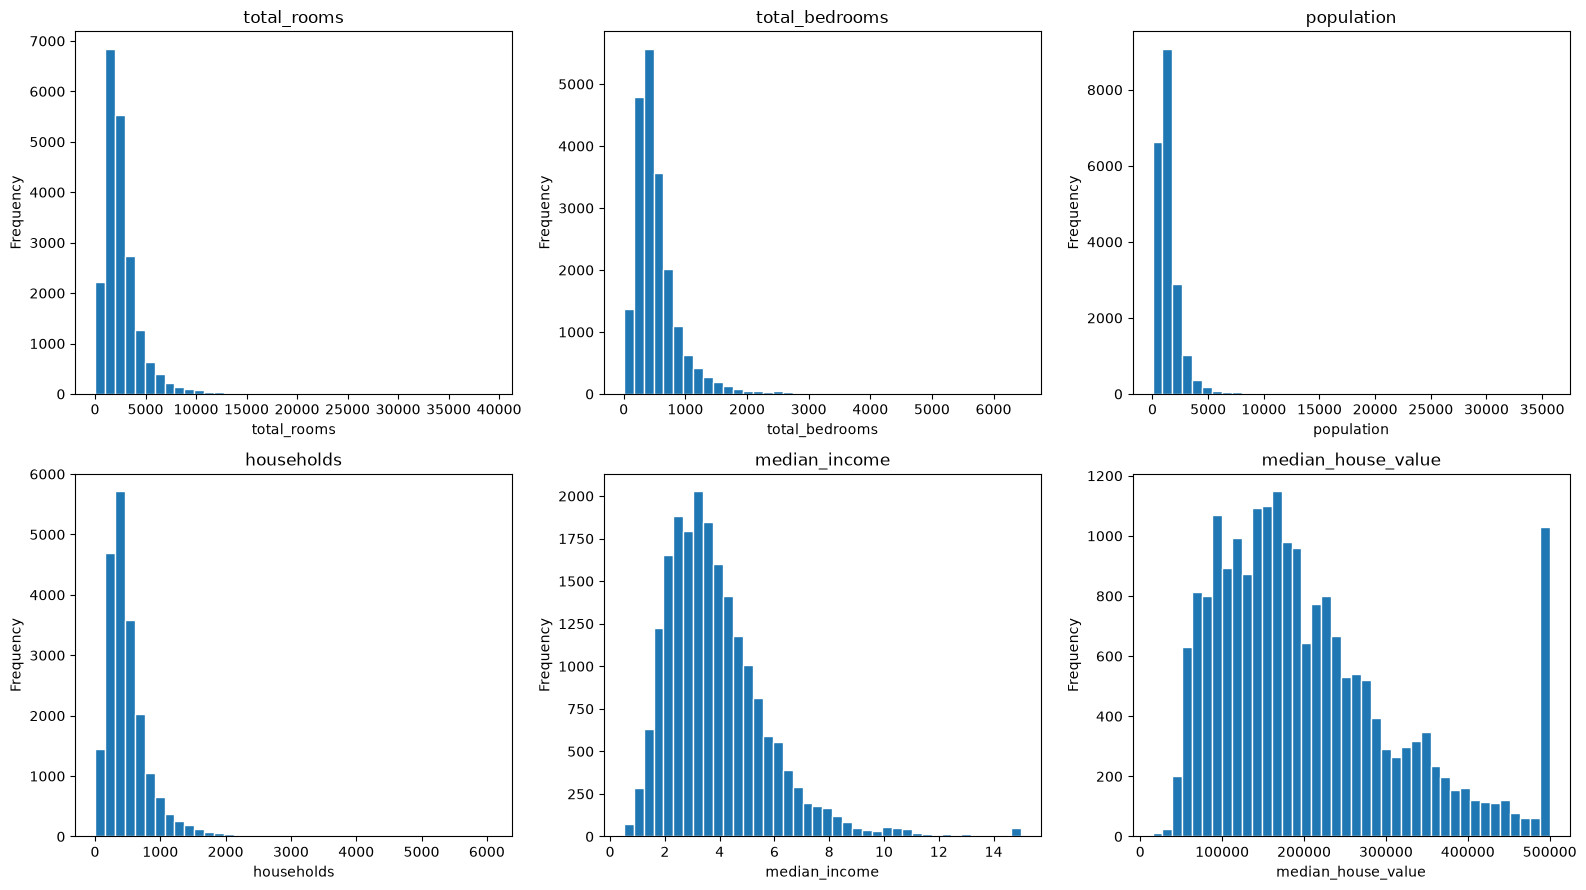


Correlation with house value:
median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
Name: median_house_value, dtype: float64


In [21]:
# EDA: inspect distributions, outliers, and relationships
count_columns = ['total_rooms', 'total_bedrooms', 'population', 'households']

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isna().sum())
print('\nSummary statistics:')
display(df[count_columns + ['median_income', 'median_house_value']].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, column in zip(axes.ravel(), count_columns + ['median_income', 'median_house_value']):
    axis.hist(df[column], bins=40, edgecolor='white')
    axis.set_title(column)
    axis.set_xlabel(column)
    axis.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print('\nCorrelation with house value:')
print(df.select_dtypes(include='number').corr()['median_house_value'].sort_values(ascending=False))

Engineered-feature summary:


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,20433.0,5.431344,2.482946,0.846154,4.441441,5.230769,6.052381,141.909091
bedrooms_per_room,20433.0,0.213039,0.057983,0.100000,0.175427,0.203162,0.239821,1.000000
population_per_household,20433.0,3.071533,10.438269,0.692308,2.429032,2.817582,3.281513,1243.333333
log_total_rooms,20433.0,7.629543,0.750260,1.098612,7.280008,7.662938,8.053251,10.579514
log_total_bedrooms,20433.0,6.054708,0.726728,0.693147,5.693732,6.077642,6.473891,8.771215
log_population,20433.0,7.025121,0.736336,1.386294,6.669498,7.062192,7.451822,10.482430
log_households,20433.0,5.984538,0.726856,0.693147,5.638355,6.016157,6.405228,8.713253



Correlation with house value:
median_house_value          1.000000
median_income               0.688355
log_total_rooms             0.158506
rooms_per_household         0.151344
log_households              0.072765
log_total_bedrooms          0.053311
log_population             -0.021904
population_per_household   -0.023639
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


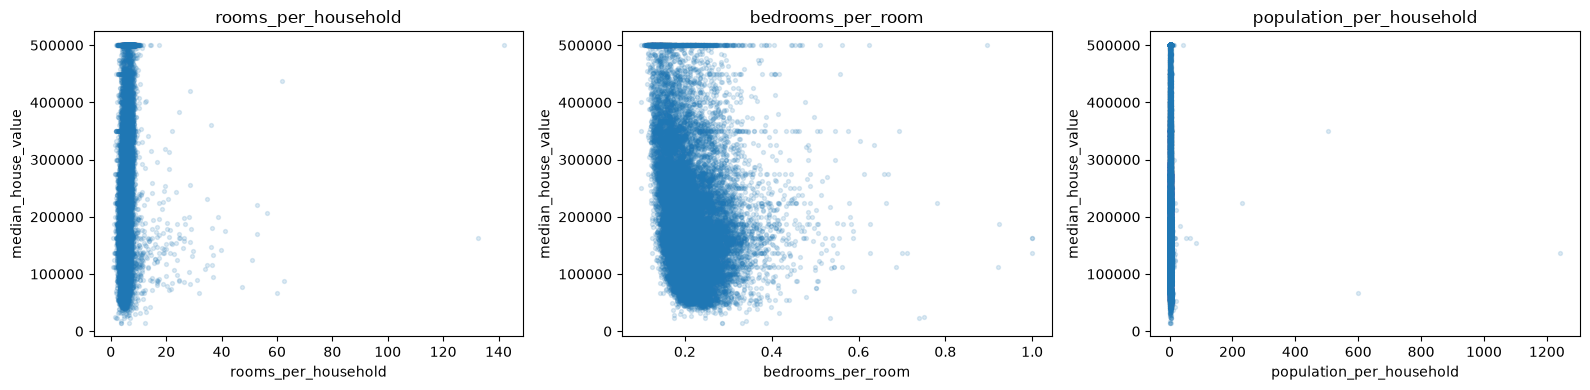

In [48]:
# Feature engineering: make block-group totals easier for a model to interpret
features = df.copy()

features['rooms_per_household'] = features['total_rooms'] / features['households']
features['bedrooms_per_room'] = features['total_bedrooms'] / features['total_rooms']
features['population_per_household'] = features['population'] / features['households']

for column in ['total_rooms', 'total_bedrooms', 'population', 'households']:
    features[f'log_{column}'] = np.log1p(features[column])

engineered_columns = [
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
    'log_total_rooms',
    'log_total_bedrooms',
    'log_population',
    'log_households',
]

print('Engineered-feature summary:')
display(features[engineered_columns].describe().T)

print('\nCorrelation with house value:')
print(features[engineered_columns + ['median_income', 'median_house_value']]
      .corr()['median_house_value']
      .sort_values(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, column in zip(axes, ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']):
    axis.scatter(features[column], features['median_house_value'], alpha=0.15, s=8)
    axis.set_title(column)
    axis.set_xlabel(column)
    axis.set_ylabel('median_house_value')
plt.tight_layout()
plt.show()

### Interpretation and next step

The scatter plots show that some ratios contain extreme outliers. For example, a block group with very few households can produce an unrealistically large `population_per_household`. These values should not automatically be deleted: first inspect them, then clip only the engineered ratios at sensible quantiles.

Main findings:
- `median_income` is the strongest single numeric predictor of house value.
- Raw totals describe neighborhood size, not the size of one house.
- `bedrooms_per_room` has a useful negative relationship with value: areas with a larger bedroom share may have smaller or lower-value homes.
- The horizontal line at `500001` is a target-value cap in the source data, not a precise price.

Recommended workflow: create ratios, log-transform skewed totals, clip extreme ratios, encode `ocean_proximity`, and compare a baseline model with the engineered-feature model.

In [23]:
# Robust engineered features for modeling
model_df = features.copy()
ratio_columns = [
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
]

for column in ratio_columns:
    lower, upper = model_df[column].quantile([0.01, 0.99])
    model_df[column] = model_df[column].clip(lower, upper)

model_df = pd.get_dummies(model_df, columns=['ocean_proximity'], dtype=int)

print('Clipped ratio ranges:')
print(model_df[ratio_columns].agg(['min', 'max']).T)
print('\nModel-ready shape:', model_df.shape)
model_df.head()

Clipped ratio ranges:
                               min        max
rooms_per_household       2.588253  10.367134
bedrooms_per_room         0.124379   0.406625
population_per_household  1.536672   5.398264

Model-ready shape: (20433, 19)


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,6.781058,4.867534,5.777652,4.844187,0,0,0,1,0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,8.867850,7.009409,7.784057,7.037906,0,0,0,1,0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,7.291656,5.252273,6.208590,5.181784,0,0,0,1,0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,7.150701,5.463832,6.326149,5.393628,0,0,0,1,0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,7.395108,5.638355,6.338594,5.560682,0,0,0,1,0


In [73]:
x = model_df.drop(columns=['median_house_value'])
y = model_df['median_house_value']

In [74]:
# 5. Train/test split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [75]:
print(x_train)

       housing_median_age  total_rooms  total_bedrooms  population  \
17727                14.0       4412.0           924.0      2698.0   
2057                 33.0       1036.0           181.0       620.0   
6453                 25.0       3891.0           848.0      1848.0   
4619                 28.0       2362.0           949.0      2759.0   
15266                27.0       1839.0           392.0      1302.0   
...                   ...          ...             ...         ...   
11397                24.0       2991.0           500.0      1437.0   
12081                 5.0       5846.0          1035.0      3258.0   
5447                 42.0       1594.0           369.0       952.0   
866                  12.0       5719.0          1064.0      3436.0   
15948                52.0       3602.0           738.0      2270.0   

       households  median_income  rooms_per_household  bedrooms_per_room  \
17727       891.0         4.7027             4.951740           0.209429   
2057   

In [76]:
from sklearn.model_selection import GridSearchCV


lr = LinearRegression()
lr.fit(x_train,y_train)




,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[ 1229.56, -0.65, -9.37,...,176597.88,-31733.33,-21497.84]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](18,)","['housing_median_age','total_rooms','total_bedrooms',..., 'ocean_proximity_ISLAND','ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.432e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(17)


In [77]:
# 6. Create Random Forest
from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)


# 7. Train
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [ ]:
# 8. Predict



y_pred = model.predict(x_test)


# 9. Evaluate
rmse = root_mean_squared_error(y_test, y_pred)

print("Random Forest RMSE:", rmse)

Random Forest RMSE: 59606.857926046


In [79]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=32,
    n_jobs=1
)


# 7. Train
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",32
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [80]:

y_pred = model.predict(x_test)


# 9. Evaluate
rmse = root_mean_squared_error(y_test, y_pred)

print("Random Forest RMSE:", rmse)

Random Forest RMSE: 59958.39782179935
